# 5.蒙特卡洛方法
蒙特卡洛方法是对数据进行反复采样并根据结果进行估计的方法的总称。在强化学习中，蒙特卡洛方法可以用来从经验中估计价值函数

## 5.1 蒙特卡洛方法的基础知识

### 5.1.1 骰子的点数和

In [1]:
# 两个骰子的概率分布
ps = {2: 1/36, 3: 2/36, 4: 3/36, 5: 4/36, 6: 5/36, 7: 6/36, 8: 5/36, 9: 4/36, 10: 3/36, 11: 2/36, 12: 1/36}

V = 0
for x, p in ps.items():
    V += x*p
print(V)

6.999999999999999


### 5.1.2 分布模型和样本模型
我们将掷骰子的试验建模为概率分布，可以将这样一个表示概率分布的模型称为分布模型  
除了分布模型，样本模型也是并表示模型的方法。样本模型是只需要采样的模型，拿骰子的例子来说，采样的意思实际是掷骰子并观测骰子的点数和。  
分布模型要求明确地持有概率分布，样本模型则要求能够进行采样

In [3]:
# 样本模型
import numpy as np

def sample(dices=2):
    x = 0
    for _ in range(dices):
        x += np.random.choice([1,2,3,4,5,6]) # 以相同概率从六个数字选取其一
    return x

可以从这个函数轻易实现从2个骰子到无数个骰子的情况。用这个样本模型计算期望值就是进行大量采样并取平均值，这就是蒙特卡洛方法

### 5.1.3 蒙特卡洛方法的实现

In [ ]:
# 一般方式
trial = 1000

samples = []

for _ in range(trial):
    s = sample()
    samples.append(s)

V = sum(samples) / len(samples) # 求平均值
print(V)

7.03


一般方式
$$
V_n = \frac{s_1+s_2+...+s_n}{n}
$$
增量方式
$$
V_n = V_{n-1} + \frac{1}{n}(s_n - V_{n-1})
$$

In [ ]:
# 增量方式 如果每次获得样本数据时都计算平均值，那么增量方式效率更高
trial = 1000
V, n = 0, 0

for _ in range(trial):
    s = sample()
    n += 1
    V += (s - V) / n
    print(V)

9.0
6.5
5.666666666666667
5.25
5.4
5.666666666666667
5.857142857142858
6.25
6.111111111111111
6.699999999999999
6.999999999999999
6.916666666666666
6.769230769230768
6.785714285714285
6.866666666666665
6.874999999999999
6.941176470588235
6.944444444444444
7.052631578947368
6.949999999999999
6.999999999999999
6.772727272727272
6.565217391304347
6.416666666666666
6.4799999999999995
6.384615384615384
6.518518518518518
6.5
6.344827586206897
6.466666666666667
6.548387096774194
6.5
6.393939393939394
6.441176470588235
6.457142857142856
6.416666666666666
6.351351351351351
6.394736842105263
6.435897435897435
6.374999999999999
6.414634146341463
6.3809523809523805
6.4186046511627906
6.5
6.511111111111111
6.5
6.553191489361702
6.583333333333333
6.591836734693877
6.619999999999999
6.666666666666666
6.634615384615384
6.584905660377358
6.629629629629629
6.636363636363636
6.678571428571428
6.6842105263157885
6.724137931034482
6.745762711864407
6.733333333333333
6.80327868852459
6.806451612903226
6.873

## 5.2 使用蒙特卡洛方法评估策略

### 5.2.1 使用蒙特卡洛方法计算价值函数
首先回顾一下价值函数
$$
v_\pi(s) = \mathbb{E}_\pi[G|s]
$$
价值函数$v_\pi(s)$被定义为根据策略$\pi$行动时获得的收益的期望值，$G$表示从状态$s$开始获得的收益  
智能代理根据策略$\pi$实际采取行动，这样得到的实际收益就是样本数据。蒙特卡洛方法会收集大量这样的样本数据，并计算他们的平均值  
$$
V_\pi(s)=\frac{G^{(1)}+G^{(2)}+...+G^{(n)}}{n}
$$
$G$表示从状态$s$开始获得的收益，用$G^{(i)}$表示在第$i$回合获得的收益

## 5.3 用蒙特卡洛方法的实现

### 5.3.1 step方法

In [4]:
from res.common.gridworld import GridWorld

env = GridWorld()
action = 0
next_state, reward, done = env.step(action)

print('next_state:', next_state)
print('reward:', reward)
print('done', done)

next_state: (1, 0)
reward: 0
done False


### 5.3.2 智能代理类的实现

In [5]:
from collections import defaultdict
import numpy as np
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0:0.25, 1:0.25, 2:0.25, 3:0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs) # 从actions按概率probs随机选取一个概率返回
    
    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory): # 反向遍历
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1 # 记录用来算平均值的次数
            self.V[state] += (G - self.V[state]) / self.cnts[state] # V_n = V_{n-1} + \frac{1}{n}(s_n - V_{n-1})

### 5.3.3 运行蒙特卡洛方法

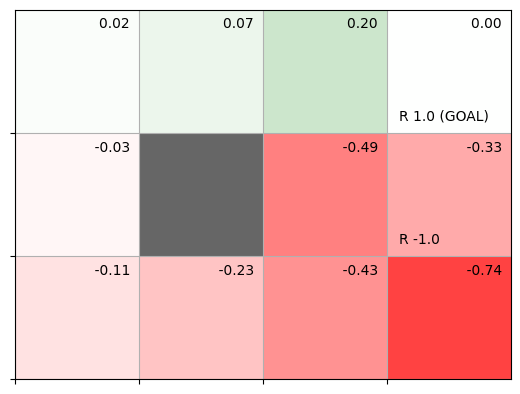

In [6]:
env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.eval()
            break

        state = next_state

env.render_v(agent.V)

## 5.4 使用蒙特卡洛方法的策略控制

### 5.4.1 评估和改进
【对状态价值函数的评估】  
一般方式：$V_n(s) = \frac{G^{(1)}+G^{(2)}+...+G^{(n)}}{n}$  
增量方式：$V_n(s) = V_{n-1}(s) + \frac{1}{n} \left\{ G^{(n)} - V_{n-1}(s) \right\}$  
【对Q函数的评估】  
一般方式：$Q_n(s,a) = \frac{G^{(1)}+G^{(2)}+...+G^{(n)}}{n}$  
增量方式：$Q_n(s,a) = Q_{n-1}(s,a) + \frac{1}{n} \left\{ G^{(n)} - Q_{n-1}(s,a) \right\}$

### 5.4.2 使用蒙特卡洛方法实现策略控制

In [ ]:
def greedy_probs(Q, state, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    action_probs = {action:0.0 for action in range(action_size)}
    action_probs[max_action] = 1
    return action_probs

class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0:0.25, 1:0.25, 2:0.25, 3:0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            self.cnts[key] += 1 # 记录状态+动作选取多少词，用来计算平均值
            '''
            self.Q[key] += (G - self.Q[key]) / self.cnts[key] # 用真实收益修正打分表Q
            '''
            alpha = 0.1
            self.Q[key] += (G - self.Q[key]) * alpha
            self.pi[state] = greedy_probs(self.Q, state) # 更新策略

### 5.4.3 $ \epsilon $ - greedy算法

In [ ]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action:base_prob for action in range(action_size)}
    # 此时的 action probs 是{0: e/4, 1: e/4, 2: e/4, 3: e/4} 
    action_probs[max_action] += (1 - epsilon)
    return action_probs

### 5.4.4 修改为固定值α的方式

In [ ]:
# alpha = 0.1
# self.Q[key] += (g - self.Q[key]) * alpha

### 5.4.5 使用蒙特卡洛方法实现策略迭代法

In [ ]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action:base_prob for action in range(action_size)}
    # 此时的 action probs 是{0: e/4, 1: e/4, 2: e/4, 3: e/4} 
    action_probs[max_action] += (1 - epsilon)
    return action_probs

class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.1
        self.action_size = 4
        
        random_actions = {0:0.25, 1:0.25, 2:0.25, 3:0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon) # 更新策略     